In [13]:
import random
import json
import itertools as it
from functools import lru_cache
from collections import namedtuple

import numpy as np
from scipy.special import softmax
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import cmocean

import jit
import mdps
import vgc_project.vgc as vgc_proj
import msdm
from vgc_project.vgc import value_guided_construal


with open("./data/procgen_grids.json") as f:
    grids = json.load(f)

with open("./data/mazes_12-15.json") as f:
    critical_grids = json.load(f)

plt.style.use("../plotStyle.mplstyle")
cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")

In [14]:
# analysis 1: compute plan utility - c * states expanded - c * objects represented
@lru_cache
def scaling_curve(grid, alpha_d, alpha_h, n_iter=100, shortcut=False):
    pars = jit.AStarPars(alpha_d, alpha_h, 0.0, False)
    # init_construal = {grid.obstacle_names.index("#")}

    n_expanded = 0
    n_construed = 0
    plan_length = 0
    n_avg_construed = 0
    for i in range(n_iter):
        # path, construal, data = jit.AStarRollout.construe_one((0, 0), grid.goal, grid, set(), pars)
        path, construal, data = jit.AStarRolloutStraight.construe_one(
            (0, 0), grid.goal, grid, set(), pars
        )
        n_construed += len(construal)
        if shortcut:
            plan_length += len(jit.shortcut(path, grid))
        else:
            plan_length += len(path)

        n_expanded += sum(len(d["visitations"]) for d in data)
        # n_avg_construed += sum((len(d["visitations"]) * len(d["construal"])) for d in data) / sum(
        n_avg_construed += sum(
            (len(d["visitations"]) * len(d["working_construal"])) for d in data
        ) / sum(len(d["visitations"]) for d in data)

    return {
        "n_expanded": n_expanded / n_iter,
        "n_construed": n_construed / n_iter,
        "n_avg_construed": n_avg_construed / n_iter,
        "plan_length": plan_length / n_iter,
    }

    # return -(plan_length / n_iter) - compute_cost * (n_expanded / n_iter) - representation_cost * (
    #     n_construed / n_iter
    # ), data


def full_search_baseline(grid, alpha_d, alpha_h, n_iter=100):
    n_expanded = 0
    plan_length = 0
    for _ in range(n_iter):
        path, visitations = jit.astar(
            grid,
            (0, 0),
            grid.goal,
            set(range(len(grid.obstacles))),
            alpha_d,
            alpha_h,
            grid.manhattan,
            False,
            True,
        )
        n_expanded += len(visitations)
        plan_length += len(path)

    return {
        "n_expanded": n_expanded / n_iter,
        "n_construed": len(grid.obstacles),
        "plan_length": plan_length / n_iter,
    }

    # return -(plan_length / n_iter) - compute_cost * (
    #     n_expanded / n_iter
    # ) - representation_cost * len(grid.obstacles), data


def random_baseline(grid, alpha_d, alpha_h, n_iter=100):
    n_expanded = 0
    n_construed = 0
    plan_length = 0

    for _ in range(n_iter):
        random_construal = set(
            random.sample(range(len(grid.obstacles)), random.randint(1, len(grid.obstacles)))
        )
        path, visitations = jit.astar(
            grid,
            (0, 0),
            grid.goal,
            random_construal,
            alpha_d,
            alpha_h,
            grid.manhattan,
            False,
            True,
        )
        n_expanded += len(visitations)
        n_construed += len(random_construal)
        # plan_length += len(path)
        if all((all(s not in o for o in grid.obstacles) for s in path)):
            plan_length += len(path)
        else:
            plan_length += 100  # V = 1 / (1 - 0.99) assuming discount=0.99

    return {
        "n_expanded": n_expanded / n_iter,
        "n_construed": len(grid.obstacles),
        "plan_length": plan_length / n_iter,
    }

    # return -(plan_length / n_iter) - compute_cost * (
    #     n_expanded / n_iter
    # ) - representation_cost * n_construed, data


@lru_cache
def vgc_search(grid, alpha_d, alpha_h, n_iter=10):
    def powerset(s, max=None):
        if max is None:
            max = len(s) + 1
        return it.chain.from_iterable(it.combinations(s, r) for r in range(max))

    construals = list(powerset(range(len(grid.obstacles))))

    iter = 0
    plan_values = []
    n_construed = 0
    expanded = 0

    vors = []
    for c in construals:
        # iter += 1
        # print(f"{iter} / {len(construals)}")
        objs = list(c)

        _plan_values = []
        _visitations = []
        for _ in range(10):
            path, visitations = jit.astar(
                grid, (0, 0), grid.goal, objs, alpha_d, alpha_h, grid.manhattan, False, True
            )
            if all((all(s not in o for o in grid.obstacles) for s in path)):
                _plan_values.append(-len(path))
            else:
                _plan_values.append(-100)  # 1 / (1 - discount) assuming discount=0.99
            _visitations.append(len(visitations))

        vors.append(sum(_plan_values) / 10 - len(objs))

        plan_values.append(sum(_plan_values) / 10)
        n_construed += len(objs)
        expanded += sum(_visitations) / 10

    return {
        "n_construed": n_construed,
        "n_expanded": expanded,
        "plan_length": -max(plan_values),
        "best_construal": len(max(zip(construals, vors), key=lambda x: x[1])[0]),
    }

In [15]:
rerun = False
if rerun:
    out = []
    # For all simulations, we use the same set of fixed search parameters
    alpha_d, alpha_h = 0.0, 1.0
    for grid_name, grid in grids.items():
        print(grid_name)
        grid = mdps.GridWorld.from_string(grid)
        baseline_data = full_search_baseline(grid, alpha_d, alpha_h)
        random_data = random_baseline(grid, alpha_d, alpha_h)
        our_data = scaling_curve(grid, alpha_d, alpha_h, n_iter=100)
        vgc_data = vgc_search(grid, alpha_d, alpha_h)
        out.append(
            [
                grid_name,
                len(grid.obstacles),
                baseline_data["n_construed"],
                baseline_data["n_expanded"],
                baseline_data["plan_length"],
                random_data["n_construed"],
                random_data["n_expanded"],
                random_data["plan_length"],
                vgc_data["n_construed"],
                vgc_data["best_construal"],
                vgc_data["n_expanded"],
                vgc_data["plan_length"],
                our_data["n_construed"],
                our_data["n_avg_construed"],
                our_data["n_expanded"],
                our_data["plan_length"],
            ]
        )
    out = pd.DataFrame(
        out,
        columns=[
            "grid",
            "nobjects",
            "full_construed",
            "full_search",
            "-full_utility",
            "random_construed",
            "random_search",
            "-random_utility",
            "vgc_construed",
            "vgc_bestconstrued",
            "vgc_search",
            "-vgc_utility",
            "ours_construed",
            "ours_avg_construed",
            "ours_search",
            "-ours_utility",
        ],
    )
    out.to_csv("./output/simulation_results.csv", index=False)
else:
    out = pd.read_csv("./output/simulation_results.csv")

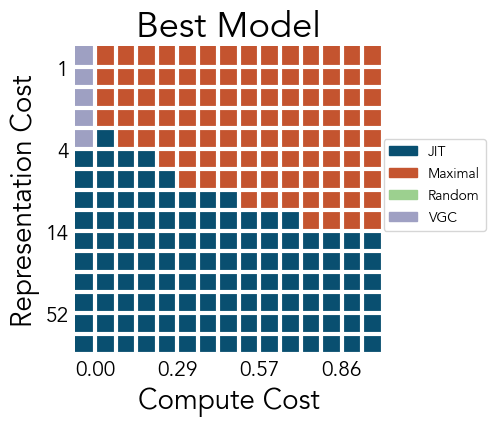

In [16]:
ys = np.linspace(0, 1, 15)
xs = np.logspace(0, 2, 15)

model_values = {
    "representation cost": [],
    "compute cost": [],
    "full_value": [],
    "our_value": [],
    "vgc_value": [],
    "random_value": [],
    "grid": [],
}
for cc in ys:
    for rc in xs:
        model_values["full_value"].extend(
            -out["-full_utility"] - cc * out["full_search"] - rc * out["full_construed"]
        )
        model_values["our_value"].extend(
            -out["-ours_utility"] - cc * out["ours_search"] - rc * out["ours_construed"]
        )
        model_values["vgc_value"].extend(
            -out["-vgc_utility"] - cc * out["vgc_search"] - rc * out["vgc_bestconstrued"]
        )
        model_values["random_value"].extend(
            -out["-random_utility"] - cc * out["random_search"] - rc * out["random_construed"]
        )
        model_values["grid"].extend(out.grid)
        model_values["representation cost"].extend([rc for _ in range(out.shape[0])])
        model_values["compute cost"].extend([cc for _ in range(out.shape[0])])

model_values = pd.DataFrame(model_values)

agg_utilities = model_values.groupby(["representation cost", "compute cost"]).sum().reset_index()

tmp = pd.merge(model_values, agg_utilities, on=["representation cost", "compute cost"], suffixes=("", "_total"))

def best_model(row):
    max_value = max(row.our_value_total, row.full_value_total, row.random_value_total, row.vgc_value_total)
    if max_value == row.our_value_total:
        return "ours"
    elif max_value == row.full_value_total:
        return "full"
    elif max_value == row.random_value_total:
        return "random"
    elif max_value == row.vgc_value_total:
        return "vgc"
    else:
        raise ValueError("No best model found!")

tmp["best"] = tmp.apply(best_model, axis=1)
agg = (
    tmp.groupby(["representation cost", "compute cost"])["best"]
    .value_counts(normalize=True)
    .reset_index()
)
# keep only the rows for which proportion is the max for that group
agg = agg.sort_values(by=["representation cost", "compute cost", "proportion"], ascending=False)
agg = agg.groupby(["representation cost", "compute cost"]).first().reset_index()

# make a heatmap of representation cost vs compute cost, assigning the best model to a different color
model_map = {
    "ours": np.array([0.0353, 0.3137, 0.4431, 1.0]),
    "full": np.array([0.7725, 0.3333, 0.1882, 1.0]),
    "vgc": np.array([0.6235, 0.6275, 0.7647, 1.0]),
    "random": np.array([0.6118, 0.8157, 0.5608, 1.0]),
}
agg["color"] = agg["best"].map(model_map)
pivot = pd.pivot(agg, index="representation cost", columns="compute cost", values="color")
N = len(pivot)
pivot = np.concatenate(pivot.to_numpy().flatten()).reshape((N, N, 4))
# colormap = mcolors.ListedColormap(["tab:blue", "tab:orange", "tab:red", "tab:green"])
colormap = mcolors.ListedColormap(
    [model_map["ours"], model_map["full"], model_map["random"], model_map["vgc"]]
)
plt.figure(figsize=(4, 4))
plt.imshow(pivot, aspect="auto", cmap=colormap, origin="upper")
plt.xticks(np.arange(xs.shape[0]) + 0.5, [f"{ys[i]:.2f}" if i % 4 == 0 else "" for i in range(15)])
plt.yticks(
    np.arange(ys.shape[0]) + 0.5,
    [f"{xs[i]:.0f}" if i % 4 == 0 else "" for i in range(15)],
)
plt.grid(which="major", color="white", lw=3)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.axis("equal")
plt.ylabel("Representation Cost")
plt.xlabel("Compute Cost")
plt.title("Best Model")
plt.legend(
    title="",
    labels=["JIT", "Maximal", "Random", "VGC"],
    handles=[
        mpatches.Patch(color=model_map["ours"], label="JIT"),
        mpatches.Patch(color=model_map["full"], label="Maximal"),
        mpatches.Patch(color=model_map["random"], label="Random"),
        mpatches.Patch(color=model_map["vgc"], label="VGC"),
    ],
    loc=(1.00, 0.4),
)
plt.savefig("../figures/rational_analysis.pdf", dpi=300, bbox_inches="tight")

In [17]:
# alternative - using full distribution instead of best construal
rerun = False
if rerun:
    repr_quality = []
    # greedy best first search
    alpha_d, alpha_h = 0.0, 1.0
    for grid_name, grid in grids.items():
        print(grid_name)
        # grid = mdps.GridWorld.from_string(grid)

        # vgc, vgc_data = vgc_search(grid, 0, 0, alpha_d, alpha_h, n_iter=10)
        construals = value_guided_construal(
            tile_array=["".join(r) for r in grid], construal_inverse_temp=10.0, discount_rate=1-1e-5
        )
        best_construal = max(construals["value_of_representation"].items(), key=lambda x: x[1])

        grid = mdps.GridWorld.from_string(grid)
        n_objects = len(grid.obstacles)

        our_data = scaling_curve(grid, alpha_d, alpha_h, n_iter=100)
        repr_quality.append(
            [
                grid_name,
                # len(best_construal[0]) / n_objects,
                sum(construals["obstacle_probs"].values()) / n_objects,
                our_data["n_construed"] / n_objects,
                n_objects,
            ]
        )
        # repr_quality.append([grid_name, len(best_construal[0]) / n_objects, our_data["n_construed"] / n_objects])

    repr_quality = pd.DataFrame(repr_quality, columns=["grid", "vgc", "ours", "n_objects"])
    repr_quality.to_csv("./output/repr_quality.csv", index=False)
else:
    # assert False
    repr_quality = pd.read_csv("./output/repr_quality.csv")

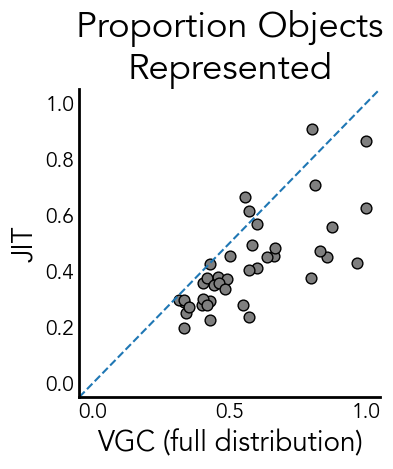

In [18]:
sns.relplot(
    repr_quality, x="vgc", y="ours", kind="scatter", s=60, ec="k", lw=1, color="tab:gray", height=4
)
plt.axline([0, 0], [1, 1], color="tab:blue", ls="--")

plt.title("Proportion Objects\nRepresented")
plt.xlabel("VGC (full distribution)")
plt.ylabel("JIT")
plt.savefig("../figures/representation_quality_comparison.pdf", dpi=300, bbox_inches="tight")

In [8]:
import random
from importlib import reload
reload(mdps)

<module 'mdps' from '/Users/tony/repos/plinko-repro/navigation/mdps.py'>

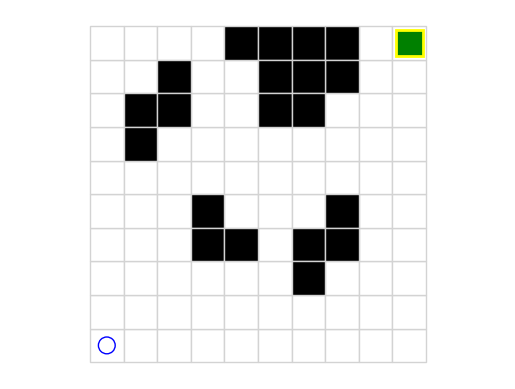

In [96]:
cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")
g = mdps.GridWorld.from_string(grids["procgen_grid_37"])
g.viz(start=(0, 0))
plt.savefig("../figures/simexample_world.pdf")

<Figure size 640x480 with 0 Axes>

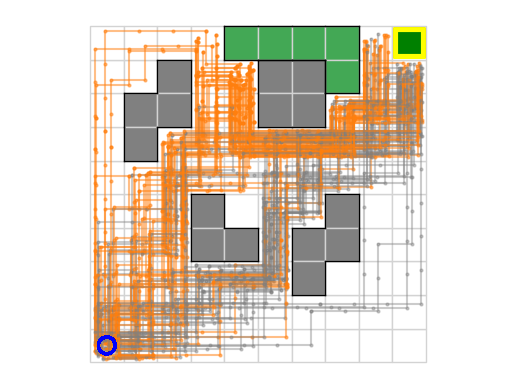

<Figure size 640x480 with 0 Axes>

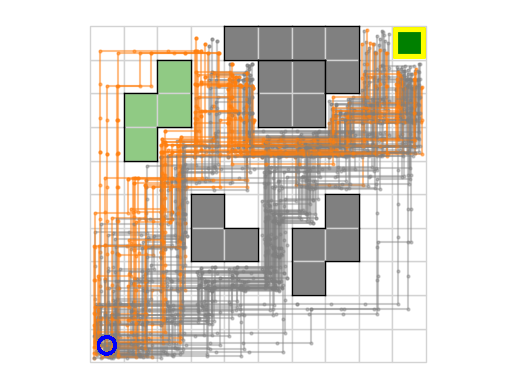

<Figure size 640x480 with 0 Axes>

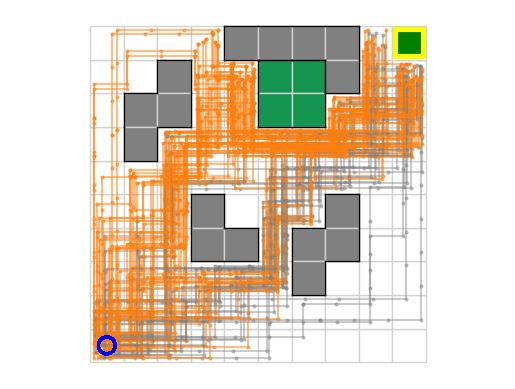

<Figure size 640x480 with 0 Axes>

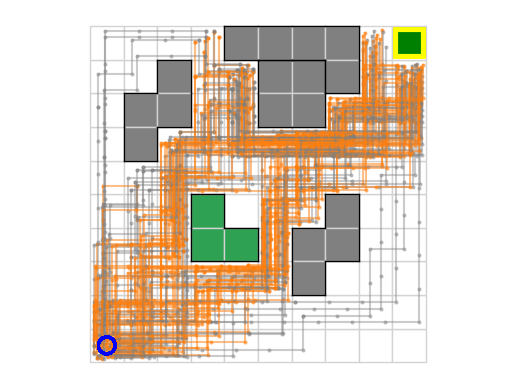

<Figure size 640x480 with 0 Axes>

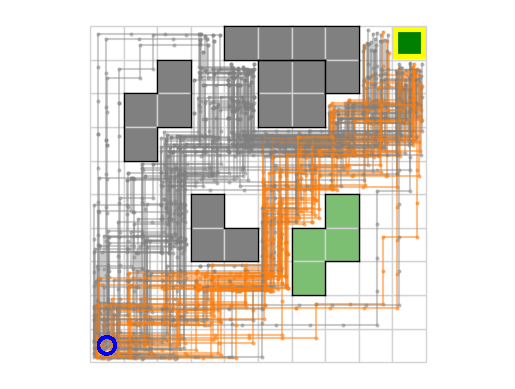

In [ ]:
g = mdps.GridWorld.from_string(grids["procgen_grid_37"])
# g.viz(labels=True)
pars = jit.AStarPars(0.0, 1.0, 0.0, False)
probs = [0] * len(g.obstacles)
paths = []
construals = []
for i in range(100):
    path, construal, data = jit.AStarRolloutStraight.construe_one((0, 0), (9, 9), g, set(), pars)
    paths.append(path)
    construals.append(construal)
    for j, v in enumerate(data[-1]["construal_traces"]):
        probs[j] += v / 100
for obj in range(len(g.obstacles)):
    plt.figure()
    colors = [cmap(v) if i == obj else "gray" for i, v in enumerate(probs)]
    g.viz(colors=colors, start=(0, 0), width=1)
    for path, construal in zip(paths, construals):
        xshift = random.random() * 0.4
        yshift = random.random() * 0.4
        xsign = 1 if random.random() < 0.5 else -1
        ysign = 1 if random.random() < 0.5 else -1
        artist = plt.Line2D(
            [p[0] + 0.5 + xshift * xsign for p in path],
            [p[1] + 0.5 + yshift * ysign for p in path],
            color="tab:orange" if obj in construal else "tab:gray",
            lw=1.5,
            alpha=0.5 if obj in construal else 0.4,
            marker="o",
            ms=2
        )
        plt.gca().add_line(artist)
        # repaint the start and goal
        plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=2))
        plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))
        plt.savefig(f"../figures/simexample_jitprocess_{obj}.pdf", dpi=300, bbox_inches="tight")
    # plt.savefig("../figures/simexample_jit_process.pdf")

In [ ]:
g = mdps.GridWorld.from_string(grids["procgen_grid_37"])
construals = value_guided_construal(
    tile_array=["".join(r) for r in grids["procgen_grid_37"]], construal_inverse_temp=10, discount_rate=1-1e-5
)
best_construal = max(construals["value_of_representation"].items(), key=lambda x: x[1])
colors = [0] * len(g.obstacles)
for o in best_construal[0]:
    colors[g.obstacle_names.index(o)] = cmap(1.0)
g.viz(colors=colors, start=(0, 0), width=1)
plt.savefig("../figures/simexample_vgc.pdf")

In [6]:
def test_construal(gridname, construal: str):
    true_maze_params = dict(
        tile_array=["".join(r) for r in grids[gridname]],
        feature_rewards=(("G", 0), ),
        absorbing_features=("G",),
        wall_features="#0123456789",
        default_features=(".",),
        initial_features=("S",),
        step_cost=-1,
        discount_rate=1.0-1e-5,
        wall_bump_cost=0,
        wall_block_prob=1.0,
        success_prob=1-1e-5,
        include_action_effect=True,
        include_wall_effect=True,
        include_terminal_state_effect=True
    )
    construed_maze = vgc_proj.ConstruedMaze(true_maze_params, construal)
    plan_res = vgc_proj.PolicyIteration().plan_on(construed_maze)
    return plan_res

def evaluate_policy(policy, gridname):
    true_maze_params = dict(
        tile_array=["".join(r) for r in grids[gridname]],
        feature_rewards=(("G", 0), ),
        absorbing_features=("G",),
        wall_features="#0123456789",
        default_features=(".",),
        initial_features=("S",),
        step_cost=-1,
        discount_rate=1.0-1e-5,
        wall_bump_cost=0,
        wall_block_prob=1.0,
        success_prob=1-1e-5,
        include_action_effect=True,
        include_wall_effect=True,
        include_terminal_state_effect=True
    )
    maze = vgc_proj.Maze(**true_maze_params)
    plan_res = policy.evaluate_on(maze) # .plan_on(construed_maze)
    return plan_res

def plot_policy(policy, grid):
    for s, dist in policy.items():
        x, y = s.x, s.y
        if (x, y) == grid.goal:
            continue
        if any((x, y) in o for o in grid.obstacles):
            continue
        for d in dist.support:
            dx, dy = d.dx, d.dy
            plt.arrow(x+0.5, y+0.5, dx * 0.25, dy * 0.25, head_width=0.3, head_length=0.2, fc='tab:orange', ec='tab:orange', alpha=0.8)
    plt.axis("equal")
    plt.axis("off")

from vgc_project.gridmdp import Location

def trace_policy(policy, grid, start, V):
    discount = 1.0 - 1e-5
    Path = namedtuple("Path", ["prob", "trajectory", "value"])
    paths = []

    stack = [Path(1.0, [start], 0)]
    timeout = 0
    while stack and timeout < 10000:
        timeout += 1
        path = stack.pop()
        # print(path)

        state = path.trajectory[-1]
        if state == grid.goal:
            paths.append(path)
            continue

        eps = -0.1
        if notvalid(state, grid) and path.value > eps:
            # print(path.trajectory[-2], V[Location(*path.trajectory[-2])])
            path = Path(path.prob, path.trajectory, V[Location(*path.trajectory[-2])] * discount ** (len(path.trajectory)-1) - sum(discount**i for i in range(len(path.trajectory)-1)))

        dist = policy[Location(*state)]
        for action in dist.support:
            successor = (state[0] + action.dx, state[1] + action.dy)
            stack.append(Path(path.prob * dist.prob(action), path.trajectory + [successor], path.value))
    return paths

def notvalid(state, grid):
    return any(state in o for o in grid.obstacles)


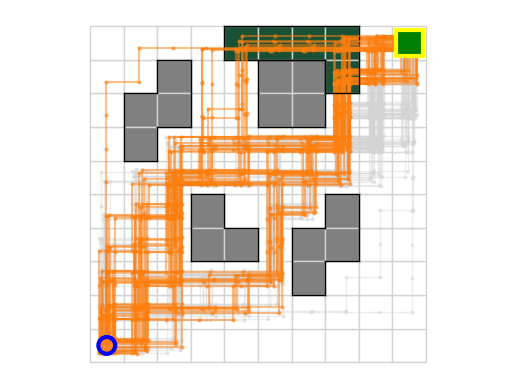

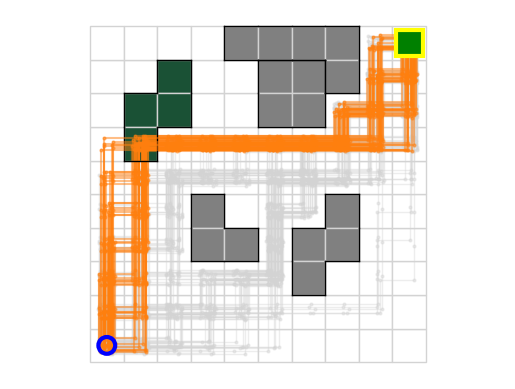

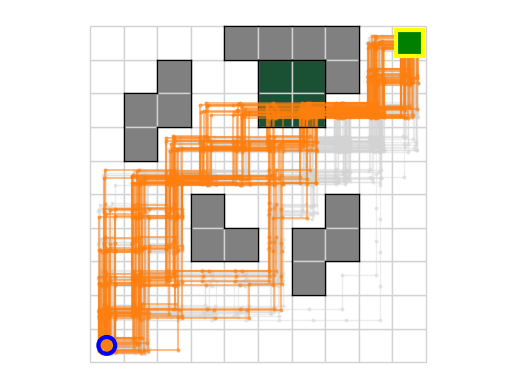

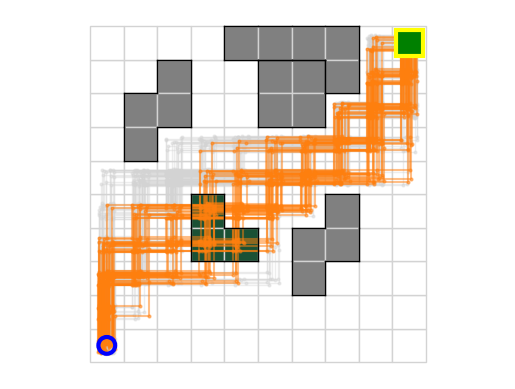

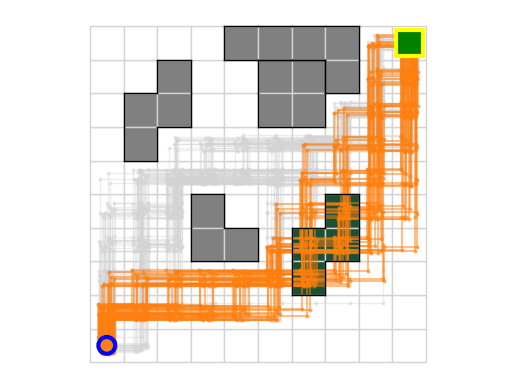

In [29]:
g = mdps.GridWorld.from_string(grids["procgen_grid_37"])
for obj in range(len(g.obstacles)):
    gridname = "procgen_grid_37"
    construal = "".join([g.obstacle_names[i] for i in range(len(g.obstacles)) if i != obj])

    res = test_construal(gridname, construal)
    V = evaluate_policy(res.policy, gridname).V
    out = trace_policy(res.policy, g, (0, 0), V)
    reds = cmocean.tools.crop_by_percent(plt.colormaps["Reds"], which="min", per=30)

    construals = value_guided_construal(
        tile_array=["".join(r) for r in grids[gridname]], construal_inverse_temp=10.0,
    )
    colors = [0] * len(g.obstacles)
    for o, v in construals["obstacle_probs"].items():
        # colors[g.obstacle_names.index(o)] = cmap(v)
        colors[g.obstacle_names.index(o)] = "gray"

    colors[obj] = cmap(v)
    g.viz(colors=colors, start=(0, 0), width=1)

    idxs = [i for i in range(len(out)) if any(g.check_collision(s) for s in out[i].trajectory)]
    badpaths = [(i, item) for i, item in enumerate(out) if i in idxs]
    goodpaths = [(i, item) for i, item in enumerate(out) if i not in idxs]

    if len(badpaths) > 100:
        badpaths = random.choices(badpaths, k=50)
    paths = random.choices(goodpaths, k=100) + badpaths
    # norm = mcolors.Normalize(vmin=0, vmax=worst_value)
    norm = mcolors.LogNorm(-max(p[1].value for p in badpaths), 1500, clip=True)

    for i, item in paths:
        path = item.trajectory

        xshift = random.random() * 0.25
        yshift = random.random() * 0.25
        # xshift = 0
        # yshift = 0
        xsign = 1 if random.random() < 0.5 else -1
        ysign = 1 if random.random() < 0.5 else -1

        pathvalue = item.value if i in idxs else len(item.trajectory)
        artist = plt.Line2D(
            [p[0] + 0.5 + xshift * xsign for p in path],
            [p[1] + 0.5 + yshift * ysign for p in path],
            # color=reds(norm(-pathvalue)) if i in idxs else "lightgray",
            color="tab:orange" if i in idxs else "lightgray",
            lw=1.5 if i in idxs else 1,
            alpha=0.5 if i in idxs else 0.4,
            zorder=2 if i in idxs and pathvalue < -50 else 1,
            marker="o",
            ms=2
        )
        plt.gca().add_line(artist)

    # repaint the start and goal
    plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=3))
    plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))
    # plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap="Reds"), label="Cost(path)", ax=plt.gca())
    plt.savefig(f"../figures/simexample_vgcprocess_{obj}.pdf", dpi=300, bbox_inches="tight")

{(0, 0): 1.0, (1, 0): 0.5099999999999999, (2, 0): 0.2499999999999999, (3, 0): 0.1299999999999999, (3, 1): 0.1899999999999999, (3, 2): 0.58, (4, 2): 0.58, (5, 2): 0.6699999999999999, (5, 3): 0.6299999999999999, (5, 4): 0.48999999999999994, (6, 4): 0.2499999999999999, (6, 5): 0.3999999999999999, (7, 5): 0.1999999999999999, (8, 5): 0.1399999999999999, (9, 5): 0.04999999999999997, (9, 6): 0.3399999999999999, (9, 7): 0.6499999999999999, (9, 8): 0.7999999999999999, (5, 5): 0.3499999999999999, (5, 6): 0.73, (6, 6): 0.94, (7, 6): 0.84, (7, 7): 0.5499999999999999, (8, 7): 0.6599999999999999, (8, 8): 0.3499999999999999, (8, 9): 0.1999999999999999, (0, 1): 0.48999999999999994, (0, 2): 0.2599999999999999, (0, 3): 0.1299999999999999, (0, 4): 0.08999999999999994, (0, 5): 0.05999999999999996, (0, 6): 0.07999999999999995, (0, 7): 0.03999999999999997, (0, 8): 0.03999999999999997, (0, 9): 0.029999999999999978, (1, 9): 0.03999999999999997, (2, 9): 0.03999999999999997, (3, 9): 0.1599999999999999, (3, 8): 

<Figure size 640x480 with 0 Axes>

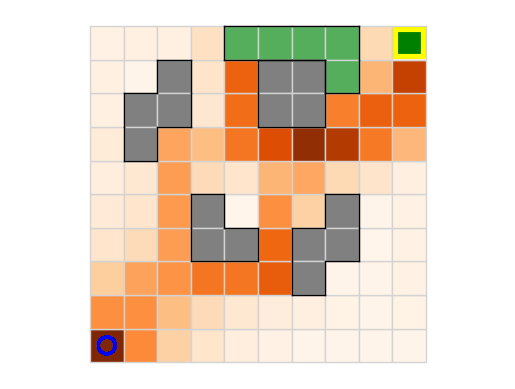

<Figure size 640x480 with 0 Axes>

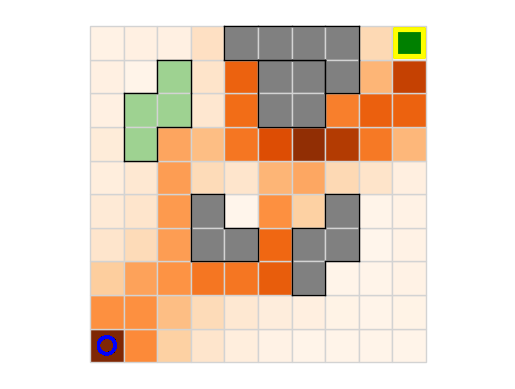

<Figure size 640x480 with 0 Axes>

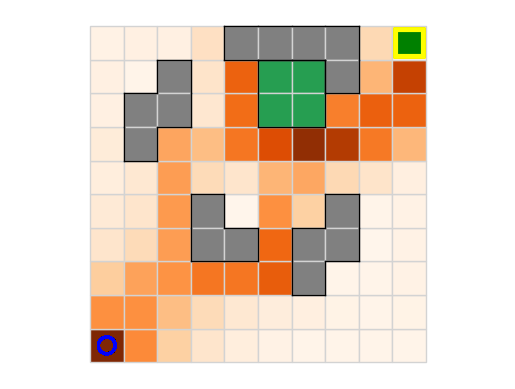

<Figure size 640x480 with 0 Axes>

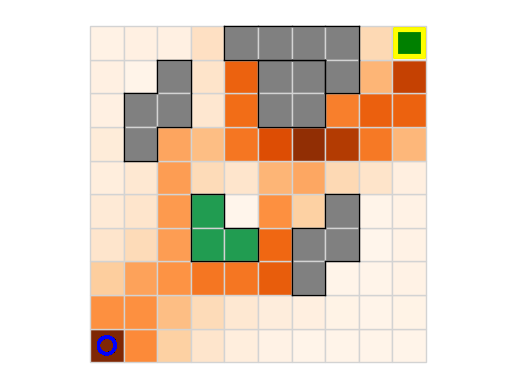

<Figure size 640x480 with 0 Axes>

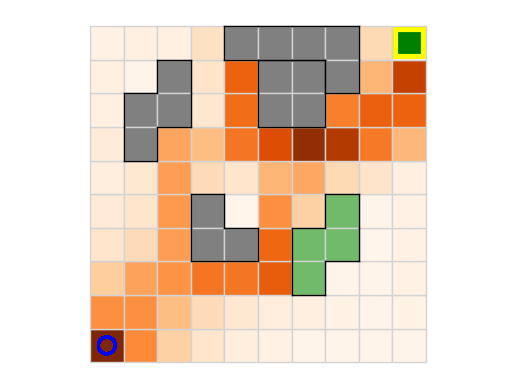

In [43]:
g = mdps.GridWorld.from_string(grids["procgen_grid_37"])
# g.viz(labels=True)
pars = jit.AStarPars(0.0, 1.0, 0.0, False)
probs = [0] * len(g.obstacles)
paths = []
construals = []
for i in range(100):
    path, construal, data = jit.AStarRolloutStraight.construe_one((0, 0), (9, 9), g, set(), pars)
    paths.append(path)
    construals.append(construal)
    for j, v in enumerate(data[-1]["construal_traces"]):
        probs[j] += v / 100

visitation_probs = {}
for path in paths:
    for step in path:
        visitation_probs[step] = visitation_probs.get(step, 0) + 1 / len(paths)
# normalize
total_visits = max(visitation_probs.values())
for key in visitation_probs:
    visitation_probs[key] /= total_visits

print(visitation_probs)

for obj in range(len(g.obstacles)):
    plt.figure()
    colors = [cmap(v) if i == obj else "gray" for i, v in enumerate(probs)]
    g.viz(colors=colors, start=(0, 0), width=1)
    patches = plt.gca().patches

    for patch in patches:
        if not isinstance(patch, plt.Rectangle):
            continue
        if any(patch.xy in o for o in g.obstacles):
            continue
        patch.set_facecolor(plt.colormaps["Oranges"](visitation_probs.get(patch.xy, 0)))
    # for path, construal in zip(paths, construals):
    #     xshift = random.random() * 0.4
    #     yshift = random.random() * 0.4
    #     xsign = 1 if random.random() < 0.5 else -1
    #     ysign = 1 if random.random() < 0.5 else -1
    #     artist = plt.Line2D(
    #         [p[0] + 0.5 + xshift * xsign for p in path],
    #         [p[1] + 0.5 + yshift * ysign for p in path],
    #         color="tab:orange" if obj in construal else "tab:gray",
    #         lw=1.5,
    #         alpha=0.5 if obj in construal else 0.4,
    #         marker="o",
    #         ms=2
    #     )
    #     plt.gca().add_line(artist)
    #     # repaint the start and goal
        plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=2))
        plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))
    #     plt.savefig(f"../figures/simexample_jitprocess_{obj}.pdf", dpi=300, bbox_inches="tight")
    # plt.savefig("../figures/simexample_jit_process.pdf")

In [131]:
badpaths

[(1548,
  Path(prob=3.0517578125e-05, trajectory=[(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (6, 5), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9), (8, 9), (9, 9)], value=-16.998640067997627)),
 (1862,
  Path(prob=0.001953125, trajectory=[(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 5), (3, 6), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)], value=-16.998640067997627)),
 (1726,
  Path(prob=0.0009765625, trajectory=[(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (3, 5), (3, 6), (3, 7), (3, 8), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)], value=-16.998640067997627)),
 (915,
  Path(prob=0.0001220703125, trajectory=[(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (3, 5), (4, 5), (5, 5), (5, 6), (6, 6), (7, 6), (7, 7), (7, 8), (7, 9), (8, 9), (9, 9)], value=-16.998640067997627)),
 (1164,
  Path(prob=0.000244140625, trajectory=[(0, 0), (0, 1), (1, 1), (2, 1), (2,

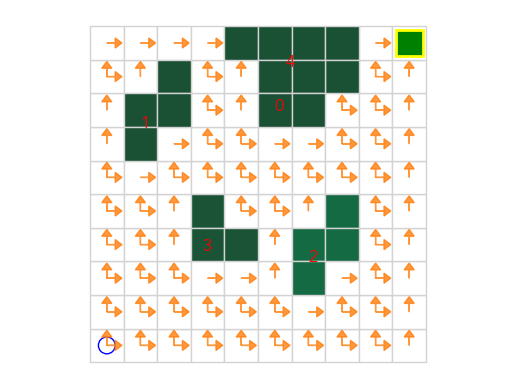

In [135]:
res = test_construal("procgen_grid_37", "0123")
construals = value_guided_construal(
    tile_array=["".join(r) for r in grids["procgen_grid_37"]], construal_inverse_temp=10.0,
)
colors = [0] * len(g.obstacles)
for o, v in construals["obstacle_probs"].items():
    colors[g.obstacle_names.index(o)] = cmap(v)
g.viz(colors=colors, labels=True, start=(0, 0))
# plt.title(f"construal=024")
plot_policy(res.policy, g)

In [ ]:
import matplotlib.patches

res = test_construal("procgen_grid_37", "0234")
V = evaluate_policy(res.policy, "procgen_grid_37").V
construal_V = res.V

out = trace_policy(res.policy, g, (0, 0), V)
reds = cmocean.tools.crop_by_percent(plt.colormaps["Reds"], which="min", per=10)
reachable_states = set([s for path in out for s in path.trajectory])

construals = value_guided_construal(
    tile_array=["".join(r) for r in grids["procgen_grid_37"]], construal_inverse_temp=10.0,
)
colors = [0] * len(g.obstacles)
for o, v in construals["obstacle_probs"].items():
    colors[g.obstacle_names.index(o)] = cmap(v)
colors[g.obstacle_names.index("1")] = "gray"
g.viz(colors=colors, start=(0, 0), width=1)


# paths = random.choices(out, k=100)
idxs = [i for i in range(len(out)) if any(g.check_collision(s) for s in out[i].trajectory)]
badpaths = [item for i, item in enumerate(out) if i in idxs]
goodpaths = [item for i, item in enumerate(out) if i not in idxs]
norm = mcolors.Normalize(vmin=0, vmax=15)
artists = plt.gca().get_children()
for patch in artists:
    if not isinstance(patch, matplotlib.patches.Rectangle):
        continue
    if g.check_collision(patch.xy):
        continue
    if not patch.xy in reachable_states:
        continue
    coord = Location(int(patch.xy[0]), int(patch.xy[1]))
    if np.isclose(V[coord] - construal_V[coord], 0):
        continue

    diff = construal_V[coord] - V[coord]
    print(diff, norm(diff))
    patch.set_facecolor(reds(norm(diff)))

paths = random.choices(goodpaths, k=100) + badpaths
for item in paths:
    path = item.trajectory

    xshift = random.random() * 0.2
    yshift = random.random() * 0.2
    # xshift = 0
    # yshift = 0
    xsign = 1 if random.random() < 0.5 else -1
    ysign = 1 if random.random() < 0.5 else -1
    for (p1, p2) in zip(path[:-1], path[1:]):
        plt.plot(
            [p1[0] + 0.5 + xshift * xsign, p2[0] + 0.5 + xshift * xsign],
            [p1[1] + 0.5 + yshift * ysign, p2[1] + 0.5 + yshift * ysign],
            "o-",
            color="lightgray",
            lw=1,
            alpha=0.2,
            ms=4
        )
# repaint the start and goal
plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=3))
plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))
plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap="Reds"), label="$\Delta$V(state)", ax=plt.gca())
# plt.savefig("../figures/theory_vgc_grid37_0234.png")

In [ ]:
import matplotlib.patches

res = test_construal("procgen_grid_37", "0134")
V = evaluate_policy(res.policy, "procgen_grid_37").V
construal_V = res.V

out = trace_policy(res.policy, g, (0, 0), V)
reds = cmocean.tools.crop_by_percent(plt.colormaps["Reds"], which="min", per=10)
reachable_states = set([s for path in out for s in path.trajectory])

construals = value_guided_construal(
    tile_array=["".join(r) for r in grids["procgen_grid_37"]], construal_inverse_temp=10.0,
)
colors = [0] * len(g.obstacles)
for o, v in construals["obstacle_probs"].items():
    colors[g.obstacle_names.index(o)] = cmap(v)
colors[g.obstacle_names.index("2")] = "gray"
g.viz(colors=colors, start=(0, 0), width=1)


# paths = random.choices(out, k=100)
idxs = [i for i in range(len(out)) if any(g.check_collision(s) for s in out[i].trajectory)]
badpaths = [item for i, item in enumerate(out) if i in idxs]
goodpaths = [item for i, item in enumerate(out) if i not in idxs]
norm = mcolors.Normalize(vmin=0, vmax=15)
artists = plt.gca().get_children()
for patch in artists:
    if not isinstance(patch, matplotlib.patches.Rectangle):
        continue
    if g.check_collision(patch.xy):
        continue
    if not patch.xy in reachable_states:
        continue
    coord = Location(int(patch.xy[0]), int(patch.xy[1]))
    if np.isclose(V[coord] - construal_V[coord], 0):
        continue

    diff = construal_V[coord] - V[coord]
    patch.set_facecolor(reds(norm(diff)))

paths = random.choices(goodpaths, k=100) + badpaths
for item in paths:
    path = item.trajectory

    xshift = random.random() * 0.1
    yshift = random.random() * 0.1
    # xshift = 0
    # yshift = 0
    xsign = 1 if random.random() < 0.5 else -1
    ysign = 1 if random.random() < 0.5 else -1
    for (p1, p2) in zip(path[:-1], path[1:]):
        plt.plot(
            [p1[0] + 0.5 + xshift * xsign, p2[0] + 0.5 + xshift * xsign],
            [p1[1] + 0.5 + yshift * ysign, p2[1] + 0.5 + yshift * ysign],
            "o-",
            color="lightgray",
            lw=1,
            alpha=0.1,
            ms=4
        )
# repaint the start and goal
plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=3))
plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))
plt.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap="Reds"), label="$\Delta$V(state)", ax=plt.gca())
# plt.savefig("../figures/theory_vgc_grid37_0234.png")

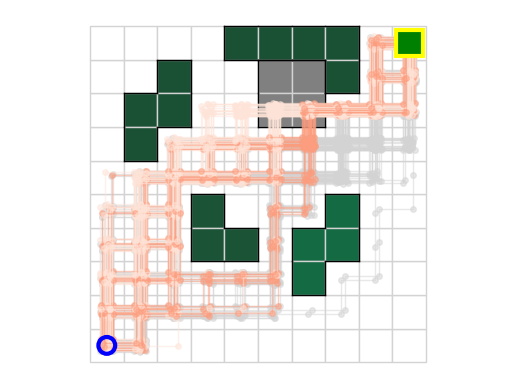

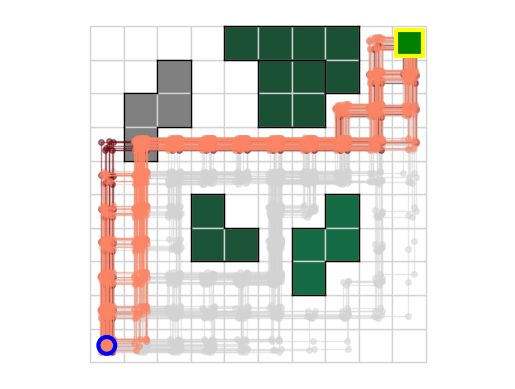

In [87]:
visualize_counterfactual("procgen_grid_37", "0234")
plt.savefig("../figures/simexample_vgc_no1.pdf")

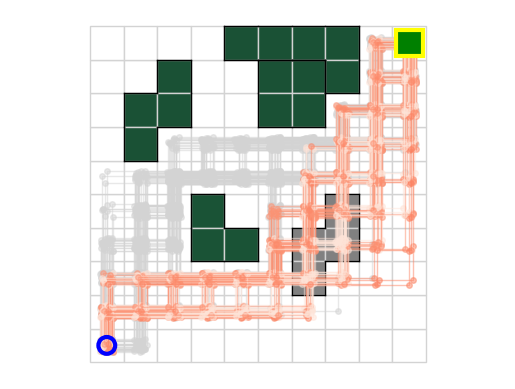

In [88]:
visualize_counterfactual("procgen_grid_37", "0134")
plt.savefig("../figures/simexample_vgc_no2.pdf")

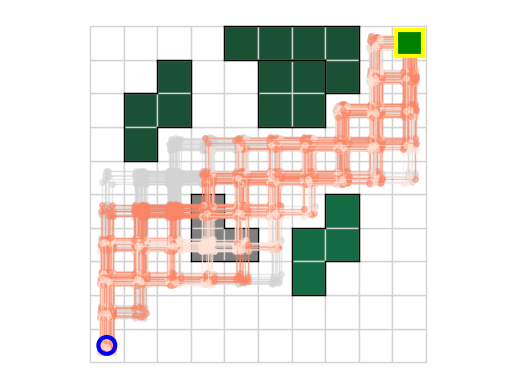

In [89]:
visualize_counterfactual("procgen_grid_37", "0124")
plt.savefig("../figures/simexample_vgc_no3.pdf")

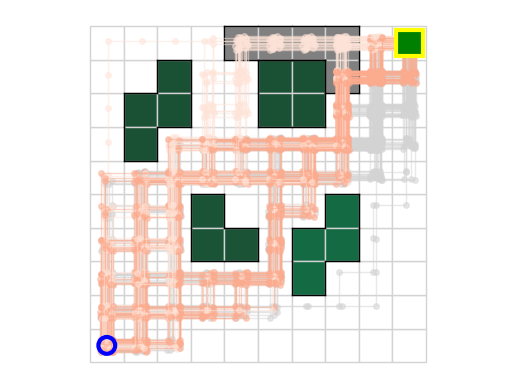

In [90]:
visualize_counterfactual("procgen_grid_37", "0123")
plt.savefig("../figures/simexample_vgc_no4.pdf")

# more demos

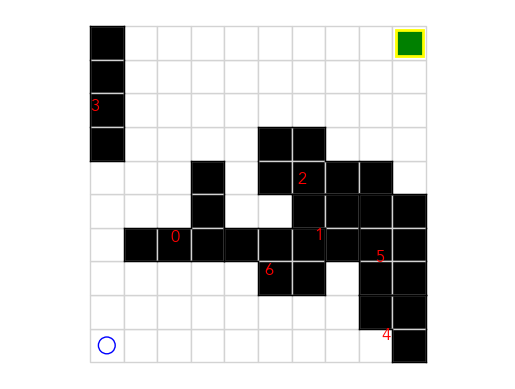

In [9]:
mdps.GridWorld.from_string(grids["procgen_grid_2"]).viz(labels=True, start=(0, 0), width=1)

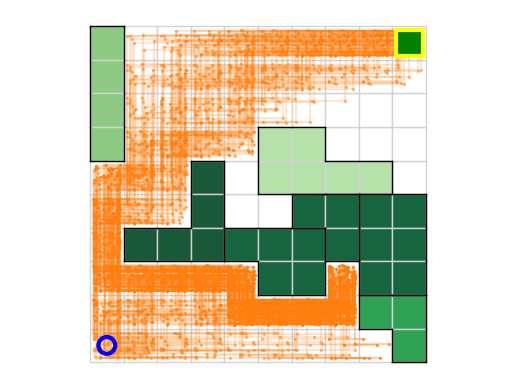

In [10]:
cmap = cmocean.tools.crop_by_percent(cmocean.cm.algae, per=20, which="max")
g = mdps.GridWorld.from_string(grids["procgen_grid_2"])
# g.viz(labels=True)
pars = jit.AStarPars(0.0, 1.0, 0.0, False)
probs = [0] * len(g.obstacles)
paths = []
for i in range(100):
    path, construal, data = jit.AStarRolloutStraight.construe_one((0, 0), (9, 9), g, set(), pars)
    paths.append(path)
    for j, v in enumerate(data[-1]["construal_traces"]):
        probs[j] += v / 100
colors = [cmap(v) for v in probs]
g.viz(colors=colors, start=(0, 0), width=1)
for path in paths:
    xshift = random.random() * 0.4
    yshift = random.random() * 0.4
    xsign = 1 if random.random() < 0.5 else -1
    ysign = 1 if random.random() < 0.5 else -1
    for (p1, p2) in zip(path, path[1:] + [g.goal]):
        plt.plot(
            [p1[0] + 0.5 + xshift * xsign, p2[0] + 0.5 + xshift * xsign],
            [p1[1] + 0.5 + yshift * ysign, p2[1] + 0.5 + yshift * ysign],
            ".-",
            color="tab:orange",
            lw=1.5,
            alpha=0.2,
            ms=3
        )
# repaint the start and goal
plt.gca().add_patch(plt.Circle((0 + 0.5, 0 + 0.5), 0.25, fc="none", ec="blue", zorder=5, lw=3))
plt.gca().add_patch(plt.Rectangle((g.goal[0] + 0.1, g.goal[1] + 0.1), 0.8, 0.8, ec="yellow", fc="green", lw=3, zorder=5))

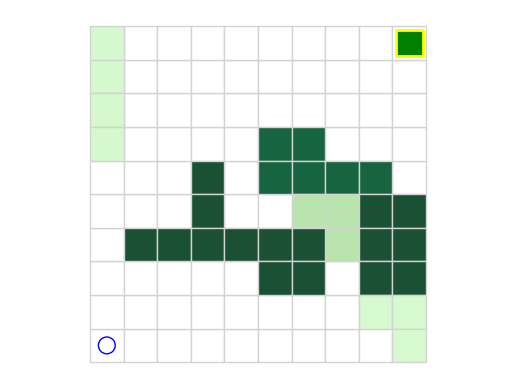

In [11]:
construals = value_guided_construal(
    tile_array=["".join(r) for r in grids["procgen_grid_2"]], construal_inverse_temp=10.0
)
colors = [0] * len(g.obstacles)
for o, v in construals["obstacle_probs"].items():
    colors[g.obstacle_names.index(o)] = cmap(v)
g.viz(colors=colors, start=(0, 0))

In [12]:
res = test_construal("procgen_grid_2", "0652")
g.viz(labels=True)
plot_policy(res.policy)


NameError: name 'test_construal' is not defined